## Gold Comparison & Evaluation (Deliverable 1.3.4)

This notebook performs the final comparison between the baseline model and the three-stage cascade. It evaluates whether the cascade meaningfully improves alert quality by reducing false positives and noisy alerts while preserving useful anomaly sensitivity.

**Purpose:**  
To combine the alert outputs from the Baseline Modeling and Cascade Modeling notebooks, compute evaluation metrics, perform paired statistical testing, and generate the comparative visualizations required for Section C.

**Key Goals:**

- Load baseline and cascade alert outputs.
- Align alerts into comparable time windows for paired evaluation.
- Compute alert-volume metrics, false-positive rates, normal-period alerts, and anomaly responsiveness.
- Perform the planned statistical significance test (paired/Wilcoxon) to quantify model differences.
- Produce comparison tables, charts, and anomaly overlays for Section C.6.
- Summarize both practical and statistical significance findings based on the project’s research question.

**Relevance to Section C:**  
This notebook fulfills the analytical requirements of C.2, C.4, C.5, and C.6 by generating:  
- The model comparison metrics,  
- The statistical significance results,  
- The practical significance interpretation, and  
- All visual communication elements needed for the final report.

This completes the Gold layer and provides the definitive evidence used to answer the project’s research question.

In [1]:
from __future__ import annotations

from dataclasses import dataclass, field
from datetime import datetime, timezone
from typing import Any, Dict, List, Optional, Sequence, Tuple, Union

from pathlib import Path
import yaml
import re

import logging
import wandb

import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 
import seaborn as sns 

import joblib 

from sklearn.model_selection import train_test_split, KFold

from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, RobustScaler

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support, roc_auc_score, average_precision_score

from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor

import pyarrow.parquet as pq
import pyarrow as pa

from IPython.display import HTML



import hashlib


# Custom Utilities Module
from utils.paths import get_paths
from utils.file_io import load_data, save_data, save_json, load_json
from utils.eda_logging import profile_dataframe
from utils.logging_setup import configure_logging, log_layer_paths
from utils.wandb_utils import finalize_wandb_stage

from utils.truths import (
    make_process_run_id,
    build_file_fingerprint,
    extract_truth_hash,
    identify_meta_columns,
    identify_feature_columns,
    initialize_layer_truth,
    update_truth_section,
    build_truth_record,
    save_truth_record,
    append_truth_index,
    stamp_truth_columns,
    load_truth_record,
    find_truth_record_by_hash,
    load_truth_record_by_hash,
    load_parent_truth_record_from_dataframe,
    get_truth_value,
    get_dataset_name_from_truth,
    get_truth_hash,
    get_parent_truth_hash,
    get_pipeline_mode_from_truth,
    get_artifact_path_from_truth,
)

from utils.pipeline_config_loader import (
    load_pipeline_config,
    build_truth_config_block,
    set_wandb_dir_from_config,
    export_config_snapshot,
)


# Ledger 
from utils.ledger import Ledger

# Show more columns
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)


----

In [ ]:
paths = get_paths()

#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 

CONFIG_ROOT = paths.configs
CONFIG_RUN_MODE = "train"
CONFIG_PROFILE = "default"

CONFIG = load_pipeline_config(
    config_root=CONFIG_ROOT,
    stage="gold_comparison",
    dataset="pump",
    mode=CONFIG_RUN_MODE,
    profile=CONFIG_PROFILE,
    project_root=paths.root,
).data

COMPARISON_CFG = CONFIG["gold_comparison"]
PATHS = CONFIG["resolved_paths"]
FILENAMES = CONFIG["filenames"]
PIPELINE = CONFIG.get(
    "pipeline",
    {
        "execution_mode": "batch",
        "orchestration_mode": "notebook",
    },
)
RUN_MODE = CONFIG["runtime"]["mode"]

TRUTH_CONFIG = build_truth_config_block(CONFIG)
TRUTH_CONFIG["pipeline"] = PIPELINE
TRUTH_CONFIG["stage_params"] = COMPARISON_CFG

# Stage Details
STAGE = "gold"
LAYER_NAME = COMPARISON_CFG["layer_name"]
GOLD_VERSION = CONFIG["versions"]["gold"]
RECIPE_ID = COMPARISON_CFG["recipe_id"]
TRUTH_VERSION = CONFIG["versions"]["truth"]
PIPELINE_MODE = PIPELINE["execution_mode"]

DATASET_NAME_CONFIG = CONFIG["dataset"]["name"]
DATASET_NAME = str(DATASET_NAME_CONFIG).strip().lower()

GOLD_PROCESS_RUN_ID = make_process_run_id(COMPARISON_CFG["process_run_id_prefix"])

# Weights and Biases
WANDB_PROJECT = CONFIG["wandb"]["project"]
WANDB_ENTITY = CONFIG["wandb"]["entity"]
WANDB_RUN_NAME = f"{GOLD_VERSION}"

# File names
BASELINE_RESULTS_FILE_NAME_CSV = FILENAMES["baseline_results_file_name_csv"]
BASELINE_RESULTS_FILE_NAME_PICKLE = FILENAMES["baseline_results_file_name_pickle"]
BASELINE_SUMMARY_FILE_NAME = FILENAMES["baseline_summary_file_name"]
BASELINE_THRESHOLDS_FILE_NAME = FILENAMES["baseline_thresholds_file_name"]
BASELINE_METADATA_FILE_NAME = FILENAMES["baseline_metadata_file_name"]

CASCADE_RESULTS_FILE_NAME_CSV = FILENAMES["cascade_results_file_name_csv"]
CASCADE_RESULTS_FILE_NAME_PICKLE = FILENAMES["cascade_results_file_name_pickle"]

CASCADE_SUMMARY_FILE_NAME = FILENAMES["cascade_summary_file_name"]
CASCADE_THRESHOLDS_FILE_NAME = FILENAMES["cascade_thresholds_file_name"]
CASCADE_METADATA_FILE_NAME = FILENAMES["cascade_metadata_file_name"]

BASELINE_VS_CASCADE_FILE_NAME = FILENAMES["baseline_vs_cascade_file_name"]
BASELINE_VS_CASCADE_SUMMARY_FILE_NAME = FILENAMES["baseline_vs_cascade_summary_file_name"]

GOLD_COMPARISON_LEDGER_FILE_NAME = FILENAMES["gold_comparison_ledger_file_name"]
COMPARISON_PLOT_WITH_TEST_ALERTS_FILE_NAME = FILENAMES["comparison_plot_with_test_alerts_file_name"]

set_wandb_dir_from_config(CONFIG)


GOLD_ARTIFACTS_PATH = Path(PATHS["gold_artifacts_dir"])

BASELINE_RESULTS_PATH_CSV = Path(PATHS["baseline_results_path_csv"])
BASELINE_RESULTS_PATH_PICKLE = Path(PATHS["baseline_results_path_pickle"])

BASELINE_THRESHOLDS_PATH = Path(PATHS["baseline_thresholds_path"])
BASELINE_SUMMARY_PATH = Path(PATHS["baseline_summary_path"])
BASELINE_METADATA_PATH = Path(PATHS["baseline_metadata_path"])

CASCADE_RESULTS_PATH_CSV = Path(PATHS["cascade_results_path_csv"])
CASCADE_RESULTS_PATH_PICKLE = Path(PATHS["cascade_results_path_pickle"])

CASCADE_THRESHOLDS_PATH = Path(PATHS["cascade_thresholds_path"])
CASCADE_SUMMARY_PATH = Path(PATHS["cascade_summary_path"])
CASCADE_METADATA_PATH = Path(PATHS["cascade_metadata_path"])


BASELINE_VS_CASCADE_PATH = Path(PATHS["baseline_vs_cascade_path"])
BASELINE_VS_CASCADE_SUMMARY_PATH = Path(PATHS["baseline_vs_cascade_summary_path"])
COMPARISON_PLOT_WITH_TEST_ALERTS_PATH = Path(PATHS["comparison_plot_with_test_alerts_path"]) 

# Logs
LOGS_PATH = Path(PATHS["logs_root"])

# Truths
TRUTHS_PATH = Path(PATHS["truths_dir"])
TRUTH_INDEX_PATH = Path(PATHS["truth_index_path"])

# Path Failsafes


GOLD_ARTIFACTS_PATH.mkdir(parents=True, exist_ok=True)
TRUTHS_PATH.mkdir(parents=True, exist_ok=True)
LOGS_PATH.mkdir(parents=True, exist_ok=True)


----

In [3]:
# Logging Setup

# Create gold log path 
gold_log_path = paths.logs / "gold_model_comparison.log"

# Initial Logger
configure_logging(
    "capstone",
    gold_log_path,
    level=logging.DEBUG,
    overwrite_handlers=True,
)

# Initiate Logger and log file
logger = logging.getLogger("capstone.gold")

# Log load and initiation
logger.info("Gold Modeling stage starting")

# Log paths loads
log_layer_paths(paths, current_layer="gold", logger=logger)


2026-03-13 07:55:23,973 | INFO | capstone.gold | Gold Modeling stage starting
2026-03-13 07:55:23,974 | INFO | capstone.gold | Project Root Path Loaded: /workspace
2026-03-13 07:55:23,975 | INFO | capstone.gold | Project Logging Path Loaded: /workspace/logs
2026-03-13 07:55:23,977 | INFO | capstone.gold | Project Artifacts Path Loaded: /workspace/artifacts
2026-03-13 07:55:23,979 | INFO | capstone.gold | Project Notebooks Path Loaded: /workspace/notebooks
2026-03-13 07:55:23,981 | INFO | capstone.gold | Project Truths Path Loaded: /workspace/artifacts/truths
2026-03-13 07:55:23,984 | INFO | capstone.gold | Project Data Path Loaded: /workspace/data
2026-03-13 07:55:23,985 | INFO | capstone.gold | Previous Layer (Silver) Path Loaded: /workspace/data/silver
2026-03-13 07:55:23,987 | INFO | capstone.gold | Previous Layer (Silver) Training Path Loaded: /workspace/data/silver/train
2026-03-13 07:55:23,988 | INFO | capstone.gold | Previous Layer (Silver) Testing Path Loaded: /workspace/data/s

----

In [4]:
# W&B

wandb_run = wandb.init(
    project=WANDB_PROJECT,
    entity=WANDB_ENTITY,
    name=WANDB_RUN_NAME,
    job_type="gold_model_comparison",
    config={
    "gold_version": GOLD_VERSION,
    "dataset": DATASET_NAME,
    "stage": STAGE,
    "baseline_results_path_csv": str(BASELINE_RESULTS_PATH_CSV),
    "baseline_results_path_pickle": str(BASELINE_RESULTS_PATH_PICKLE),
    "baseline_summary_path": str(BASELINE_SUMMARY_PATH),
    "cascade_results_path_csv": str(CASCADE_RESULTS_PATH_CSV),
    "cascade_results_path_pickle": str(CASCADE_RESULTS_PATH_PICKLE),
    "cascade_summary_path": str(CASCADE_SUMMARY_PATH),
    },
)
logger.info("W&B initialized: %s", wandb.run.name)


wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: dcoo230 (dcoo230-western-governors-university). Use `wandb login --relogin` to force relogin


2026-03-13 07:55:29,379 | INFO | capstone.gold | W&B initialized: gold__001


----

In [5]:
# Ledger Setup

ledger = Ledger(stage=STAGE, recipe_id=RECIPE_ID)

ledger.add(
    kind="step",
    step="init",
    message="Initialized ledger",
    logger=logger
)


2026-03-13 07:55:29,764 | INFO | capstone.gold | LEDGER | {'ts_utc': '2026-03-13T07:55:29.764643+00:00', 'stage': 'gold', 'recipe': 'gold_modeling__v001_model_comparision', 'kind': 'step', 'step': 'init', 'message': 'Initialized ledger', 'why': None, 'consequence': None, 'data': {}}


{'ts_utc': '2026-03-13T07:55:29.764643+00:00',
 'stage': 'gold',
 'recipe': 'gold_modeling__v001_model_comparision',
 'kind': 'step',
 'step': 'init',
 'message': 'Initialized ledger',
 'why': None,
 'consequence': None,
 'data': {}}

----

In [6]:
baseline_results_csv = pd.read_csv(BASELINE_RESULTS_PATH_CSV)
baseline_results_pickle = pd.read_pickle(BASELINE_RESULTS_PATH_PICKLE)

baseline_results = baseline_results_csv

baseline_summary = load_json(BASELINE_SUMMARY_PATH)
baseline_thresholds = load_json(BASELINE_THRESHOLDS_PATH)
baseline_metadata = load_json(BASELINE_METADATA_PATH)

cascade_results_csv = pd.read_csv(CASCADE_RESULTS_PATH_CSV)
cascade_results_pickle = pd.read_pickle(CASCADE_RESULTS_PATH_PICKLE)

cascade_results = cascade_results_csv

cascade_summary = load_json(CASCADE_SUMMARY_PATH)
cascade_thresholds = load_json(CASCADE_THRESHOLDS_PATH)
cascade_metadata = load_json(CASCADE_METADATA_PATH)

# -------------------------------------------------------------------
# Resolve and validate Baseline stage truth
# -------------------------------------------------------------------
BASELINE_TRUTH_HASH = baseline_metadata.get("baseline_truth_hash")
BASELINE_TRUTH_PATH_VALUE = baseline_metadata.get("baseline_truth_path")

if BASELINE_TRUTH_HASH is None:
    raise ValueError("baseline_metadata is missing 'baseline_truth_hash'.")
if BASELINE_TRUTH_PATH_VALUE is None:
    raise ValueError("baseline_metadata is missing 'baseline_truth_path'.")

BASELINE_TRUTH_PATH = Path(BASELINE_TRUTH_PATH_VALUE)
if not BASELINE_TRUTH_PATH.exists():
    raise FileNotFoundError(f"Baseline truth file not found: {BASELINE_TRUTH_PATH}")

baseline_truth = load_json(BASELINE_TRUTH_PATH)

if baseline_truth.get("truth_hash") != BASELINE_TRUTH_HASH:
    raise ValueError(
        "Baseline metadata truth hash does not match the loaded baseline truth file:\n"
        f"metadata={BASELINE_TRUTH_HASH}\n"
        f"truth_file={baseline_truth.get('truth_hash')}"
    )

baseline_results_truth_hash = extract_truth_hash(baseline_results)
if baseline_results_truth_hash is None:
    raise ValueError("Could not resolve meta__truth_hash from baseline_results CSV.")

if baseline_results_truth_hash != BASELINE_TRUTH_HASH:
    raise ValueError(
        "Baseline results CSV truth hash does not match baseline_metadata['baseline_truth_hash']:\n"
        f"csv={baseline_results_truth_hash}\n"
        f"metadata={BASELINE_TRUTH_HASH}"
    )

BASELINE_PARENT_GOLD_TRUTH_HASH = get_parent_truth_hash(baseline_truth)
if BASELINE_PARENT_GOLD_TRUTH_HASH is None:
    raise ValueError("baseline_truth is missing a usable parent_truth_hash.")

baseline_truth_runtime_facts = baseline_truth.get("runtime_facts", {})
baseline_truth_artifact_paths = baseline_truth.get("artifact_paths", {})

# -------------------------------------------------------------------
# Resolve and validate Cascade stage truth
# -------------------------------------------------------------------
CASCADE_TRUTH_HASH = cascade_metadata.get("cascade_truth_hash")
CASCADE_TRUTH_PATH_VALUE = cascade_metadata.get("cascade_truth_path")

if CASCADE_TRUTH_HASH is None:
    raise ValueError("cascade_metadata is missing 'cascade_truth_hash'.")
if CASCADE_TRUTH_PATH_VALUE is None:
    raise ValueError("cascade_metadata is missing 'cascade_truth_path'.")

CASCADE_TRUTH_PATH = Path(CASCADE_TRUTH_PATH_VALUE)
if not CASCADE_TRUTH_PATH.exists():
    raise FileNotFoundError(f"Cascade truth file not found: {CASCADE_TRUTH_PATH}")

cascade_truth = load_json(CASCADE_TRUTH_PATH)

if cascade_truth.get("truth_hash") != CASCADE_TRUTH_HASH:
    raise ValueError(
        "Cascade metadata truth hash does not match the loaded cascade truth file:\n"
        f"metadata={CASCADE_TRUTH_HASH}\n"
        f"truth_file={cascade_truth.get('truth_hash')}"
    )

cascade_results_truth_hash = extract_truth_hash(cascade_results)
if cascade_results_truth_hash is None:
    raise ValueError("Could not resolve meta__truth_hash from cascade_results CSV.")

if cascade_results_truth_hash != CASCADE_TRUTH_HASH:
    raise ValueError(
        "Cascade results CSV truth hash does not match cascade_metadata['cascade_truth_hash']:\n"
        f"csv={cascade_results_truth_hash}\n"
        f"metadata={CASCADE_TRUTH_HASH}"
    )

CASCADE_PARENT_GOLD_TRUTH_HASH = get_parent_truth_hash(cascade_truth)
if CASCADE_PARENT_GOLD_TRUTH_HASH is None:
    raise ValueError("cascade_truth is missing a usable parent_truth_hash.")

if BASELINE_PARENT_GOLD_TRUTH_HASH != CASCADE_PARENT_GOLD_TRUTH_HASH:
    raise ValueError(
        "Baseline and Cascade truth records do not point to the same parent Gold truth:\n"
        f"baseline_parent={BASELINE_PARENT_GOLD_TRUTH_HASH}\n"
        f"cascade_parent={CASCADE_PARENT_GOLD_TRUTH_HASH}"
    )

GOLD_PARENT_TRUTH_HASH = BASELINE_PARENT_GOLD_TRUTH_HASH

DATASET_NAME = get_dataset_name_from_truth(baseline_truth)
CASCADE_DATASET_NAME = get_dataset_name_from_truth(cascade_truth)

if DATASET_NAME != CASCADE_DATASET_NAME:
    raise ValueError(
        "Baseline and Cascade truth records do not share the same dataset_name:\n"
        f"baseline_dataset={DATASET_NAME}\n"
        f"cascade_dataset={CASCADE_DATASET_NAME}"
    )

PIPELINE_MODE_FROM_BASELINE_TRUTH = get_pipeline_mode_from_truth(baseline_truth)
if PIPELINE_MODE_FROM_BASELINE_TRUTH is not None:
    PIPELINE_MODE = PIPELINE_MODE_FROM_BASELINE_TRUTH

GOLD_TRUTH_PATH = (
    TRUTHS_PATH
    / "gold"
    / f"{DATASET_NAME}__gold__truth__{GOLD_PARENT_TRUTH_HASH}.json"
)

if not GOLD_TRUTH_PATH.exists():
    raise FileNotFoundError(f"Gold truth file not found: {GOLD_TRUTH_PATH}")

gold_truth = load_json(GOLD_TRUTH_PATH)
gold_truth_runtime_facts = gold_truth.get("runtime_facts", {})
gold_truth_artifact_paths = gold_truth.get("artifact_paths", {})

logger.info("Resolved comparison dataset name from baseline/cascade truth: %s", DATASET_NAME)
logger.info("Resolved shared Gold parent truth hash: %s", GOLD_PARENT_TRUTH_HASH)

print("Comparison dataset name from truth:", DATASET_NAME)
print("Shared Gold parent truth hash:", GOLD_PARENT_TRUTH_HASH)



ledger.add(
    kind="step",
    step="load_comparison_inputs",
    message="Loaded baseline/cascade outputs, validated their stage truth records, confirmed both point to the same Gold truth, and loaded the shared Gold truth file.",
    data={
        "baseline_results_path_csv": str(BASELINE_RESULTS_PATH_CSV),
        "baseline_results_path_pickle": str(BASELINE_RESULTS_PATH_PICKLE),
        "baseline_summary_path": str(BASELINE_SUMMARY_PATH),
        "baseline_thresholds_path": str(BASELINE_THRESHOLDS_PATH),
        "baseline_metadata_path": str(BASELINE_METADATA_PATH),
        "baseline_truth_hash": BASELINE_TRUTH_HASH,
        "baseline_truth_path": str(BASELINE_TRUTH_PATH),
        "baseline_results_truth_hash": baseline_results_truth_hash,
        "cascade_results_path_csv": str(CASCADE_RESULTS_PATH_CSV),
        "cascade_results_path_pickle": str(CASCADE_RESULTS_PATH_PICKLE),
        "cascade_summary_path": str(CASCADE_SUMMARY_PATH),
        "cascade_thresholds_path": str(CASCADE_THRESHOLDS_PATH),
        "cascade_metadata_path": str(CASCADE_METADATA_PATH),
        "cascade_truth_hash": CASCADE_TRUTH_HASH,
        "cascade_truth_path": str(CASCADE_TRUTH_PATH),
        "cascade_results_truth_hash": cascade_results_truth_hash,
        "gold_truth_path": str(GOLD_TRUTH_PATH),
        "gold_truth_hash": GOLD_PARENT_TRUTH_HASH,
        "baseline_result_rows": int(len(baseline_results)),
        "cascade_result_rows": int(len(cascade_results)),
    },
    logger=logger,
)

baseline_results.head(3)

2026-03-13 07:55:36,952 | INFO | capstone.file_io | Loading JSON: /workspace/artifacts/gold/pump/pump__gold__baseline_summary.json
2026-03-13 07:55:36,963 | INFO | capstone.file_io | Loading JSON: /workspace/artifacts/gold/pump/pump__gold__baseline_thresholds.json
2026-03-13 07:55:36,977 | INFO | capstone.file_io | Loading JSON: /workspace/artifacts/gold/pump/pump__gold__baseline_metadata.json
2026-03-13 07:55:44,406 | INFO | capstone.file_io | Loading JSON: /workspace/artifacts/gold/pump/pump__gold__cascade_summary.json
2026-03-13 07:55:44,418 | INFO | capstone.file_io | Loading JSON: /workspace/artifacts/gold/pump/pump__gold__cascade_thresholds.json
2026-03-13 07:55:44,434 | INFO | capstone.file_io | Loading JSON: /workspace/artifacts/gold/pump/pump__gold__cascade_metadata.json
2026-03-13 07:55:44,456 | INFO | capstone.file_io | Loading JSON: /workspace/artifacts/truths/gold_baseline/pump__gold_baseline__truth__7cba150e44500159c11cf82a26f73769b09137200b299a02a82e02767d4b89de.json
202

Comparison dataset name from truth: pump
Shared Gold parent truth hash: 52040214a1b81f683312ca3f97704c6d08e7bbcfe03b984952cffa6954826a1f


,meta__asset_id,meta__dataset,meta__episode_id,meta__event_id,meta__ingested_at_utc,meta__parent_truth_hash,meta__pipeline_mode,meta__record_id,meta__run_id,meta__source_file,meta__source_row_id,meta__split,meta__truth_hash,event_time,event_step,time_index,event_date,anomaly_flag,is_anomaly,is_normal,status_normal_value,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,sensor_08,sensor_09,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,sensor_22,sensor_23,sensor_24,sensor_25,sensor_26,sensor_27,sensor_28,sensor_29,sensor_30,sensor_31,sensor_32,sensor_33,sensor_34,sensor_35,sensor_36,sensor_37,sensor_38,sensor_39,sensor_40,sensor_41,sensor_42,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_51,timestamp,machine_status,meta__is_train_flag,baseline_score,baseline_flag
0,asset__001,pump,0,pump:asset__001:run__001:0,2026-03-13 06:35:15.530983+00:00,52040214a1b81f683312ca3f97704c6d08e7bbcfe03b98...,batch,14598431322315673869,run__001,sensor.csv,0,train,7cba150e44500159c11cf82a26f73769b09137200b299a...,2018-04-01 00:00:00+00:00,0,0,2018-04-01 00:00:00+00:00,0,0,1,NORMAL,0.232560,-0.509807,0.537036,1.090905,0.227271,-0.144184,-0.212771,0.000000,0.633343,-0.133358,-0.966540,0.663285,-0.099631,-0.152932,0.001485,-0.017980,0.259816,0.203007,0.012069,0.001266,0.026039,-0.004667,0.375041,0.470634,0.054448,0.018867,-0.398656,-0.746314,-0.137762,-0.554838,-1.070844,-0.832376,-0.653530,-0.038647,-0.157592,-0.223411,0.170945,-1.156251,-0.909090,0.527273,-0.909090,-0.882353,-0.125000,0.000000,4.000000,0.928571,-0.608697,0.715953,1.900001,0.014598,2018-04-01 00:00:00,NORMAL,True,0.391431,0
1,asset__001,pump,0,pump:asset__001:run__001:1,2026-03-13 06:35:15.530983+00:00,52040214a1b81f683312ca3f97704c6d08e7bbcfe03b98...,batch,15954729095895098000,run__001,sensor.csv,1,train,7cba150e44500159c11cf82a26f73769b09137200b299a...,2018-04-01 00:01:00+00:00,1,1,2018-04-01 00:00:00+00:00,0,0,1,NORMAL,0.232560,-0.509807,0.537036,1.090905,0.227271,-0.144184,-0.212771,0.000000,0.633343,-0.133358,-0.966540,0.663285,-0.099631,-0.152932,0.001485,-0.017980,0.259816,0.203007,0.012069,0.001266,0.026039,-0.004667,0.375041,0.470634,0.054448,0.018867,-0.398656,-0.746314,-0.137762,-0.554838,-1.070844,-0.832376,-0.653530,-0.038647,-0.157592,-0.223411,0.170945,-1.156251,-0.909090,0.527273,-0.909090,-0.882353,-0.125000,0.000000,4.000000,0.928571,-0.608697,0.715953,1.900001,0.014598,2018-04-01 00:01:00,NORMAL,True,0.391431,0
2,asset__001,pump,0,pump:asset__001:run__001:2,2026-03-13 06:35:15.530983+00:00,52040214a1b81f683312ca3f97704c6d08e7bbcfe03b98...,batch,10041703297090838359,run__001,sensor.csv,2,train,7cba150e44500159c11cf82a26f73769b09137200b299a...,2018-04-01 00:02:00+00:00,2,2,2018-04-01 00:00:00+00:00,0,0,1,NORMAL,-0.255821,-0.392159,0.537036,1.127271,0.670453,-0.485083,-0.468102,-0.185694,0.750017,-0.333349,-0.869635,0.742744,0.084552,-0.140848,0.063680,0.024252,-0.023257,-0.051481,0.031807,0.039803,0.034031,0.045869,0.539582,0.559032,0.045512,0.031031,-0.029962,-0.769896,-0.025671,0.380643,-0.866485,-0.748481,-0.586075,-0.053782,-0.147948,-0.214093,0.276319,-1.031250,-0.954545,0.454546,-0.999999,-0.882353,-0.166667,-0.045454,3.954546,0.964285,-0.608696,0.688715,1.833334,0.072992,2018-04-01 00:02:00,NORMAL,True,0.384923,0


----

In [7]:
baseline_flags = baseline_results["baseline_flag"]
baseline_scores = baseline_results["baseline_score"]

stage1_flags = cascade_results["stage1_flag"]
stage2_flags = cascade_results["stage2_flag"]
final_flags = cascade_results["cascade_final_flag"]

stage1_scores = cascade_results["stage1_score"]
stage2_scores = cascade_results["stage2_score"]


# Alert counts and metrics

# Baseline
baseline_alert_count_all_rows = baseline_summary["alert_count_all_rows"]
baseline_alert_count_test_rows = baseline_summary["alert_count_test_rows"]
baseline_metrics = baseline_summary["baseline_metrics"]

# Cascade
stage1_alert_count_all_rows = cascade_summary["stage1_alert_count_all_rows"]
stage2_alert_count_all_rows = cascade_summary["stage2_alert_count_all_rows"]
final_cascade_alert_count_all_rows = cascade_summary["final_cascade_alert_count_all_rows"]

stage1_alert_count_test_rows = cascade_summary["stage1_alert_count_test_rows"]
stage2_alert_count_test_rows = cascade_summary["stage2_alert_count_test_rows"]
final_cascade_alert_count_test_rows = cascade_summary["final_cascade_alert_count_test_rows"]

cascade_metrics = cascade_summary["cascade_metrics"]


comparison_rows = [
    {
        "model": "Baseline IsolationForest",
        "alert_count_all_rows": int(baseline_alert_count_all_rows),
        "alert_count_test_rows": int(baseline_alert_count_test_rows),
        "precision": baseline_metrics.get("precision"),
        "recall": baseline_metrics.get("recall"),
        "f1": baseline_metrics.get("f1"),
        "stage_truth_hash": BASELINE_TRUTH_HASH,
        "parent_gold_truth_hash": GOLD_PARENT_TRUTH_HASH,
    },
    {
        "model": "Cascade Final",
        "alert_count_all_rows": int(final_cascade_alert_count_all_rows),
        "alert_count_test_rows": int(final_cascade_alert_count_test_rows),
        "precision": cascade_metrics.get("precision"),
        "recall": cascade_metrics.get("recall"),
        "f1": cascade_metrics.get("f1"),
        "stage_truth_hash": CASCADE_TRUTH_HASH,
        "parent_gold_truth_hash": GOLD_PARENT_TRUTH_HASH,
    },
]
comparison_df = pd.DataFrame(comparison_rows)


alert_reduction_count = (
    int(baseline_alert_count_test_rows) - int(final_cascade_alert_count_test_rows)
)
alert_reduction_ratio = alert_reduction_count / max(
    int(baseline_alert_count_test_rows), 1
)

comparison_summary = {
    "baseline_alert_count_test_rows": int(baseline_alert_count_test_rows),
    "stage1_alert_count_test_rows": int(stage1_alert_count_test_rows),
    "stage2_alert_count_test_rows": int(stage2_alert_count_test_rows),
    "final_cascade_alert_count_test_rows": int(final_cascade_alert_count_test_rows),
    "alert_reduction_count": int(alert_reduction_count),
    "alert_reduction_ratio": float(alert_reduction_ratio),

    "baseline_precision": baseline_metrics.get("precision"),
    "baseline_recall": baseline_metrics.get("recall"),
    "baseline_f1": baseline_metrics.get("f1"),

    "cascade_precision": cascade_metrics.get("precision"),
    "cascade_recall": cascade_metrics.get("recall"),
    "cascade_f1": cascade_metrics.get("f1"),

    # Stage truth linkage
    "baseline_truth_hash": BASELINE_TRUTH_HASH,
    "baseline_truth_path": str(BASELINE_TRUTH_PATH),
    "baseline_process_run_id": baseline_truth.get("process_run_id"),
    "baseline_parent_gold_truth_hash": BASELINE_PARENT_GOLD_TRUTH_HASH,

    "cascade_truth_hash": CASCADE_TRUTH_HASH,
    "cascade_truth_path": str(CASCADE_TRUTH_PATH),
    "cascade_process_run_id": cascade_truth.get("process_run_id"),
    "cascade_parent_gold_truth_hash": CASCADE_PARENT_GOLD_TRUTH_HASH,

    # Shared Gold truth linkage
    "gold_truth_hash": GOLD_PARENT_TRUTH_HASH,
    "gold_truth_path": str(GOLD_TRUTH_PATH),
    "gold_process_run_id": gold_truth.get("process_run_id"),
    "gold_feature_set_id": gold_truth_runtime_facts.get("feature_set_id"),

    # CSV stamp validation
    "baseline_results_truth_hash": baseline_results_truth_hash,
    "cascade_results_truth_hash": cascade_results_truth_hash,
}

----

In [8]:
styled = (
    comparison_df
    .style.format({
        "alert_count_all_rows": "{:,}",
        "alert_count_test_rows": "{:,}", 
        "precision": "{:.3f}",
        "recall": "{:.3f}",
        "f1": "{:.3f}",
    })
    .set_caption("Gold Model Performance Comparison: Baseline vs Cascade")
)
display(HTML(styled.to_html()))

,model,alert_count_all_rows,alert_count_test_rows,precision,recall,f1,stage_truth_hash,parent_gold_truth_hash
0,Baseline IsolationForest,"19,493","1,522",0.047,0.602,0.087,7cba150e44500159c11cf82a26f73769b09137200b299a02a82e02767d4b89de,52040214a1b81f683312ca3f97704c6d08e7bbcfe03b984952cffa6954826a1f
1,Cascade Final,"16,501","1,166",0.056,0.551,0.101,492f9c11a23db61aa611865e6625971618d39b70a194f76fc3caaadf3e9e5c34,52040214a1b81f683312ca3f97704c6d08e7bbcfe03b984952cffa6954826a1f


In [9]:
# --- 2-panel plot: alerts (test) + metrics ---
metrics_to_plot = ["precision", "recall", "f1"]

plot_df = comparison_df.copy()
for m in metrics_to_plot:
    plot_df[m] = pd.to_numeric(plot_df[m], errors="coerce").fillna(0.0)

plot_df["alert_count_test_rows"] = pd.to_numeric(
    plot_df["alert_count_test_rows"], errors="coerce"
).fillna(0).astype(int)

models = plot_df["model"].tolist()

fig, (ax_alerts, ax_metrics) = plt.subplots(1, 2, figsize=(11, 4.5))

# Alerts (test)
bars = ax_alerts.bar(models, plot_df["alert_count_test_rows"].values)
ax_alerts.set_title("Test Alert Counts")
ax_alerts.set_ylabel("Alerts")
ax_alerts.grid(axis="y", alpha=0.3)

# Label bars (optional but helpful)
for b in bars:
    ax_alerts.text(
        b.get_x() + b.get_width() / 2,
        b.get_height(),
        f"{int(b.get_height()):,}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

# Metrics grouped bars
x = np.arange(len(metrics_to_plot))
width = 0.35
values = np.vstack([plot_df[m].values for m in metrics_to_plot])  # (3, n_models)

for i, model in enumerate(models):
    offset = (i - (len(models) - 1) / 2) * width
    ax_metrics.bar(x + offset, values[:, i], width=width, label=model)

ax_metrics.set_xticks(x)
ax_metrics.set_xticklabels([m.upper() for m in metrics_to_plot])
ax_metrics.set_ylim(0, 1.0)
ax_metrics.set_title("Precision / Recall / F1")
ax_metrics.set_ylabel("Score")
ax_metrics.legend()
ax_metrics.grid(axis="y", alpha=0.3)

fig.tight_layout()

plot_path = GOLD_ARTIFACTS_PATH / COMPARISON_PLOT_WITH_TEST_ALERTS_FILE_NAME
fig.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.close(fig)

print(f"Saved comparison plot to: {plot_path}")

if "wandb_run" in globals() and wandb_run is not None:
    wandb_run.log({"gold/comparison_plot_test_alerts_and_metrics": wandb.Image(str(plot_path))})
    wandb_run.log({"gold/model_comparison_table": wandb.Table(dataframe=comparison_df)})

    # optional extra summary table
    wandb_run.log({
        "gold/baseline_vs_cascade_summary": wandb.Table(
            dataframe=pd.DataFrame([comparison_summary])
        )
    })

Saved comparison plot to: /workspace/artifacts/gold/pump/pump__gold__comparison__2panel_test_alerts_and_metrics.png


----

In [10]:
'''
# --- Metrics bar plot (robust to None/NaN) ---
metrics_to_plot = ["precision", "recall", "f1"]

plot_df = comparison_df.copy()
for m in metrics_to_plot:
    plot_df[m] = pd.to_numeric(plot_df[m], errors="coerce").fillna(0.0)

models = plot_df["model"].tolist()
n_models = len(models)
n_metrics = len(metrics_to_plot)

values = np.vstack([plot_df[m].values for m in metrics_to_plot])  # (n_metrics, n_models)

x = np.arange(n_metrics)
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

for i, model in enumerate(models):
    offset = (i - (n_models - 1) / 2) * width
    ax.bar(x + offset, values[:, i], width=width, label=model)

ax.set_xticks(x)
ax.set_xticklabels([m.upper() for m in metrics_to_plot])
ax.set_ylabel("Score")
ax.set_ylim(0, 1.0)
ax.set_title("Gold Model Performance: Precision / Recall / F1")
ax.legend()
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

# Save as artifact
plot_path = GOLD_ARTIFACTS_PATH / COMPARISON_PLOT_FILE_NAME
fig.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.close(fig)

print(f"Saved comparison plot to: {plot_path}")

# W&B logging
if "wandb_run" in globals() and wandb_run is not None:
    wandb_run.log({"gold/comparison_plot": wandb.Image(str(plot_path))})
    wandb_run.log({"gold/model_comparison_table": wandb.Table(dataframe=comparison_df)})

'''

'\n# --- Metrics bar plot (robust to None/NaN) ---\nmetrics_to_plot = ["precision", "recall", "f1"]\n\nplot_df = comparison_df.copy()\nfor m in metrics_to_plot:\n    plot_df[m] = pd.to_numeric(plot_df[m], errors="coerce").fillna(0.0)\n\nmodels = plot_df["model"].tolist()\nn_models = len(models)\nn_metrics = len(metrics_to_plot)\n\nvalues = np.vstack([plot_df[m].values for m in metrics_to_plot])  # (n_metrics, n_models)\n\nx = np.arange(n_metrics)\nwidth = 0.35\n\nfig, ax = plt.subplots(figsize=(8, 5))\n\nfor i, model in enumerate(models):\n    offset = (i - (n_models - 1) / 2) * width\n    ax.bar(x + offset, values[:, i], width=width, label=model)\n\nax.set_xticks(x)\nax.set_xticklabels([m.upper() for m in metrics_to_plot])\nax.set_ylabel("Score")\nax.set_ylim(0, 1.0)\nax.set_title("Gold Model Performance: Precision / Recall / F1")\nax.legend()\nax.grid(axis="y", alpha=0.3)\n\nfig.tight_layout()\n\n# Save as artifact\nplot_path = GOLD_ARTIFACTS_PATH / COMPARISON_PLOT_FILE_NAME\nfig.sav

----

In [11]:

'''

# --- 2-panel plot: alerts (test) + metrics ---
metrics_to_plot = ["precision", "recall", "f1"]

plot_df = comparison_df.copy()
for m in metrics_to_plot:
    plot_df[m] = pd.to_numeric(plot_df[m], errors="coerce").fillna(0.0)

models = plot_df["model"].tolist()
x_models = np.arange(len(models))

fig, ax = plt.subplots(figsize=(9, 6))

# Panel 1: Test alert counts
if "alert_count_test_rows" in plot_df.columns:
    ax.bar(x_models - 0.2, plot_df["alert_count_test_rows"].values, width=0.4, label="Test Alerts")
    ax.set_xticks(x_models)
    ax.set_xticklabels(models, rotation=0)
    ax.set_ylabel("Alert Count (Test Rows)")
    ax.set_title("Gold Alerts (Test) and Metrics")

# Create a second axis for metrics bars (scaled 0-1)
ax2 = ax.twinx()

# Panel 2: Metrics grouped bars (right axis)
x = np.arange(len(metrics_to_plot))
width = 0.35
values = np.vstack([plot_df[m].values for m in metrics_to_plot])

# shift metrics group to the right of the alert bars visually
base = len(models) + 1.5
x_metrics = base + x

for i, model in enumerate(models):
    offset = (i - (len(models) - 1) / 2) * width
    ax2.bar(x_metrics + offset, values[:, i], width=width, label=f"{model} Metrics")

ax2.set_ylim(0, 1.0)
ax2.set_ylabel("Metric Score (0–1)")
ax2.set_xticks(list(x_models) + list(x_metrics))
ax2.set_xticklabels(models + [m.upper() for m in metrics_to_plot])

# Legend: combine both axes
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(handles1 + handles2, labels1 + labels2, loc="upper right")

ax.grid(axis="y", alpha=0.3)
fig.tight_layout()

plot_path = GOLD_ARTIFACTS_PATH / COMPARISON_PLOT_2_PANEL_FILE_NAME
fig.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.close(fig)

print(f"Saved comparison plot to: {plot_path}")

if "wandb_run" in globals() and wandb_run is not None:
    wandb_run.log({"gold/comparison_plot": wandb.Image(str(plot_path))})
    wandb_run.log({"gold/model_comparison_table": wandb.Table(dataframe=comparison_df)})

'''

'\n\n# --- 2-panel plot: alerts (test) + metrics ---\nmetrics_to_plot = ["precision", "recall", "f1"]\n\nplot_df = comparison_df.copy()\nfor m in metrics_to_plot:\n    plot_df[m] = pd.to_numeric(plot_df[m], errors="coerce").fillna(0.0)\n\nmodels = plot_df["model"].tolist()\nx_models = np.arange(len(models))\n\nfig, ax = plt.subplots(figsize=(9, 6))\n\n# Panel 1: Test alert counts\nif "alert_count_test_rows" in plot_df.columns:\n    ax.bar(x_models - 0.2, plot_df["alert_count_test_rows"].values, width=0.4, label="Test Alerts")\n    ax.set_xticks(x_models)\n    ax.set_xticklabels(models, rotation=0)\n    ax.set_ylabel("Alert Count (Test Rows)")\n    ax.set_title("Gold Alerts (Test) and Metrics")\n\n# Create a second axis for metrics bars (scaled 0-1)\nax2 = ax.twinx()\n\n# Panel 2: Metrics grouped bars (right axis)\nx = np.arange(len(metrics_to_plot))\nwidth = 0.35\nvalues = np.vstack([plot_df[m].values for m in metrics_to_plot])\n\n# shift metrics group to the right of the alert bars vi

----

In [12]:
'''


metrics_to_plot = ["precision", "recall", "f1"]

plot_df = comparison_df.copy()
for m in metrics_to_plot:
    plot_df[m] = pd.to_numeric(plot_df[m], errors="coerce").fillna(0.0)

plot_df["alert_count_test_rows"] = pd.to_numeric(
    plot_df["alert_count_test_rows"], errors="coerce"
).fillna(0).astype(int)

models = plot_df["model"].tolist()

fig, (ax_alerts, ax_metrics) = plt.subplots(1, 2, figsize=(11, 4.5))

# --- Alerts (test) ---
ax_alerts.bar(models, plot_df["alert_count_test_rows"].values)
ax_alerts.set_title("Test Alert Counts")
ax_alerts.set_ylabel("Alerts")
ax_alerts.grid(axis="y", alpha=0.3)

# --- Metrics grouped bars ---
x = np.arange(len(metrics_to_plot))
width = 0.35
values = np.vstack([plot_df[m].values for m in metrics_to_plot])  # (3, n_models)

for i, model in enumerate(models):
    offset = (i - (len(models) - 1) / 2) * width
    ax_metrics.bar(x + offset, values[:, i], width=width, label=model)

ax_metrics.set_xticks(x)
ax_metrics.set_xticklabels([m.upper() for m in metrics_to_plot])
ax_metrics.set_ylim(0, 1.0)
ax_metrics.set_title("Precision / Recall / F1")
ax_metrics.set_ylabel("Score")
ax_metrics.legend()
ax_metrics.grid(axis="y", alpha=0.3)

fig.tight_layout()

plot_path = GOLD_ARTIFACTS_PATH / COMPARISON_PLOT_WITH_TEST_ALERTS_FILE_NAME
fig.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.close(fig)

print(f"Saved comparison plot to: {plot_path}")

if "wandb_run" in globals() and wandb_run is not None:
    wandb_run.log({"gold/comparison_plot": wandb.Image(str(plot_path))})
    wandb_run.log({"gold/model_comparison_table": wandb.Table(dataframe=comparison_df)})

'''

'\n\n\nmetrics_to_plot = ["precision", "recall", "f1"]\n\nplot_df = comparison_df.copy()\nfor m in metrics_to_plot:\n    plot_df[m] = pd.to_numeric(plot_df[m], errors="coerce").fillna(0.0)\n\nplot_df["alert_count_test_rows"] = pd.to_numeric(\n    plot_df["alert_count_test_rows"], errors="coerce"\n).fillna(0).astype(int)\n\nmodels = plot_df["model"].tolist()\n\nfig, (ax_alerts, ax_metrics) = plt.subplots(1, 2, figsize=(11, 4.5))\n\n# --- Alerts (test) ---\nax_alerts.bar(models, plot_df["alert_count_test_rows"].values)\nax_alerts.set_title("Test Alert Counts")\nax_alerts.set_ylabel("Alerts")\nax_alerts.grid(axis="y", alpha=0.3)\n\n# --- Metrics grouped bars ---\nx = np.arange(len(metrics_to_plot))\nwidth = 0.35\nvalues = np.vstack([plot_df[m].values for m in metrics_to_plot])  # (3, n_models)\n\nfor i, model in enumerate(models):\n    offset = (i - (len(models) - 1) / 2) * width\n    ax_metrics.bar(x + offset, values[:, i], width=width, label=model)\n\nax_metrics.set_xticks(x)\nax_metric

----

In [13]:
comparison_summary["gold_truth_hash"] = GOLD_PARENT_TRUTH_HASH
comparison_summary["gold_truth_path"] = str(GOLD_TRUTH_PATH)
comparison_summary["gold_process_run_id"] = gold_truth.get("process_run_id")
comparison_summary["gold_feature_set_id"] = gold_truth_runtime_facts.get("feature_set_id")

truth_config_snapshot = (
    TRUTH_CONFIG
    if "TRUTH_CONFIG" in globals()
    else {
        "runtime": {
            "stage": "gold_comparison",
            "dataset": DATASET_NAME,
            "mode": RUN_MODE if "RUN_MODE" in globals() else None,
            "profile": CONFIG_PROFILE if "CONFIG_PROFILE" in globals() else "default",
        }
    }
)

comparison_truth_layer_name = "gold_comparison"
comparison_process_run_id = (
    GOLD_PROCESS_RUN_ID
    if "GOLD_PROCESS_RUN_ID" in globals()
    else make_process_run_id("gold_comparison_process")
)

comparison_truth = initialize_layer_truth(
    truth_version=TRUTH_VERSION,
    dataset_name=DATASET_NAME,
    layer_name=comparison_truth_layer_name,
    process_run_id=comparison_process_run_id,
    pipeline_mode=PIPELINE_MODE,
    parent_truth_hash=GOLD_PARENT_TRUTH_HASH,
)

comparison_truth = update_truth_section(
    comparison_truth,
    "config_snapshot",
    truth_config_snapshot,
)

comparison_truth = update_truth_section(
    comparison_truth,
    "runtime_facts",
    {
        "comparison_row_count": int(len(comparison_df)),
        "baseline_result_row_count": int(len(baseline_results)),
        "cascade_result_row_count": int(len(cascade_results)),
        "shared_gold_truth_hash": GOLD_PARENT_TRUTH_HASH,
        "baseline_truth_hash": baseline_metadata.get("baseline_truth_hash"),
        "cascade_truth_hash": cascade_metadata.get("cascade_truth_hash"),
        "baseline_model_name": baseline_summary.get("baseline_metrics", {}).get("model"),
        "cascade_model_name": cascade_summary.get("cascade_metrics", {}).get("model"),
    },
)

comparison_truth = update_truth_section(
    comparison_truth,
    "artifact_paths",
    {
        "gold_truth_path": str(GOLD_TRUTH_PATH),
        "baseline_results_path_csv": str(BASELINE_RESULTS_PATH_CSV),
        "baseline_results_path_pickle": str(BASELINE_RESULTS_PATH_PICKLE),
        "baseline_summary_path": str(BASELINE_SUMMARY_PATH),
        "baseline_thresholds_path": str(BASELINE_THRESHOLDS_PATH),
        "baseline_metadata_path": str(BASELINE_METADATA_PATH),
        "cascade_results_path_csv": str(CASCADE_RESULTS_PATH_CSV),
        "cascade_results_path_pickle": str(CASCADE_RESULTS_PATH_PICKLE),
        "cascade_summary_path": str(CASCADE_SUMMARY_PATH),
        "cascade_thresholds_path": str(CASCADE_THRESHOLDS_PATH),
        "cascade_metadata_path": str(CASCADE_METADATA_PATH),
        "baseline_vs_cascade_path": str(BASELINE_VS_CASCADE_PATH),
        "baseline_vs_cascade_summary_path": str(BASELINE_VS_CASCADE_SUMMARY_PATH),
        "comparison_plot_with_test_alerts_path": str(plot_path) if "plot_path" in globals() else None,
    },
)

comparison_meta_columns = sorted(
    set(
        identify_meta_columns(comparison_df)
        + [
            "meta__truth_hash",
            "meta__parent_truth_hash",
            "meta__pipeline_mode",
        ]
    )
)

comparison_feature_columns = identify_feature_columns(comparison_df)

comparison_truth_record = build_truth_record(
    truth_base=comparison_truth,
    row_count=len(comparison_df),
    column_count=comparison_df.shape[1] + 3,
    meta_columns=comparison_meta_columns,
    feature_columns=comparison_feature_columns,
)

COMPARISON_TRUTH_HASH = comparison_truth_record["truth_hash"]

comparison_df = stamp_truth_columns(
    comparison_df,
    truth_hash=COMPARISON_TRUTH_HASH,
    parent_truth_hash=GOLD_PARENT_TRUTH_HASH,
    pipeline_mode=PIPELINE_MODE,
)

comparison_truth_path = save_truth_record(
    comparison_truth_record,
    truth_dir=TRUTHS_PATH,
    dataset_name=DATASET_NAME,
    layer_name=comparison_truth_layer_name,
)

append_truth_index(
    comparison_truth_record,
    truth_index_path=TRUTH_INDEX_PATH,
)

comparison_summary["comparison_truth_hash"] = COMPARISON_TRUTH_HASH
comparison_summary["comparison_truth_path"] = str(comparison_truth_path)
comparison_summary["comparison_process_run_id"] = comparison_process_run_id

comparison_df.to_csv(BASELINE_VS_CASCADE_PATH, index=False)
save_json(comparison_summary, BASELINE_VS_CASCADE_SUMMARY_PATH)

if "wandb_run" in globals() and wandb_run is not None:
    wandb_run.save(str(BASELINE_VS_CASCADE_PATH))
    wandb_run.save(str(BASELINE_VS_CASCADE_SUMMARY_PATH))
    wandb_run.save(str(comparison_truth_path))

ledger.add(
    kind="step",
    step="save_comparison_outputs",
    message="Saved final baseline versus cascade comparison outputs and comparison stage truth record.",
    data={
        "comparison_csv": str(BASELINE_VS_CASCADE_PATH),
        "comparison_summary_json": str(BASELINE_VS_CASCADE_SUMMARY_PATH),
        "comparison_rows": int(len(comparison_df)),
        "gold_truth_hash": GOLD_PARENT_TRUTH_HASH,
        "gold_truth_path": str(GOLD_TRUTH_PATH),
        "comparison_truth_hash": COMPARISON_TRUTH_HASH,
        "comparison_truth_path": str(comparison_truth_path),
    },
    logger=logger,
)

2026-03-13 07:55:48,090 | INFO | capstone.file_io | Saved JSON: /workspace/artifacts/gold/pump/pump__gold__baseline_vs_cascade_summary.json
wandb: WARNING Saving files without folders. If you want to preserve subdirectories pass base_path to wandb.save, i.e. wandb.save("/mnt/folder/file.h5", base_path="/mnt")
2026-03-13 07:55:48,219 | INFO | capstone.gold | LEDGER | {'ts_utc': '2026-03-13T07:55:48.219443+00:00', 'stage': 'gold', 'recipe': 'gold_modeling__v001_model_comparision', 'kind': 'step', 'step': 'save_comparison_outputs', 'message': 'Saved final baseline versus cascade comparison outputs and comparison stage truth record.', 'why': None, 'consequence': None, 'data': {'comparison_csv': '/workspace/artifacts/gold/pump/pump__gold__baseline_vs_cascade.csv', 'comparison_summary_json': '/workspace/artifacts/gold/pump/pump__gold__baseline_vs_cascade_summary.json', 'comparison_rows': 2, 'gold_truth_hash': '52040214a1b81f683312ca3f97704c6d08e7bbcfe03b984952cffa6954826a1f', 'gold_truth_pat

{'ts_utc': '2026-03-13T07:55:48.219443+00:00',
 'stage': 'gold',
 'recipe': 'gold_modeling__v001_model_comparision',
 'kind': 'step',
 'step': 'save_comparison_outputs',
 'message': 'Saved final baseline versus cascade comparison outputs and comparison stage truth record.',
 'why': None,
 'consequence': None,
 'data': {'comparison_csv': '/workspace/artifacts/gold/pump/pump__gold__baseline_vs_cascade.csv',
  'comparison_summary_json': '/workspace/artifacts/gold/pump/pump__gold__baseline_vs_cascade_summary.json',
  'comparison_rows': 2,
  'gold_truth_hash': '52040214a1b81f683312ca3f97704c6d08e7bbcfe03b984952cffa6954826a1f',
  'gold_truth_path': '/workspace/artifacts/truths/gold/pump__gold__truth__52040214a1b81f683312ca3f97704c6d08e7bbcfe03b984952cffa6954826a1f.json',
  'comparison_truth_hash': '3b9dfd95185f4b136e4fef1c8a6a8f22e4496e50b16045ed514e7285245850c8',
  'comparison_truth_path': '/workspace/artifacts/truths/gold_comparison/pump__gold_comparison__truth__3b9dfd95185f4b136e4fef1c8a6

----

In [14]:
ledger.add(
    kind="step",
    step="finalize_comparison",
    message="Gold comparison notebook complete.",
    data={
        "comparison_csv": str(BASELINE_VS_CASCADE_PATH),
        "comparison_summary_json": str(BASELINE_VS_CASCADE_SUMMARY_PATH),
        "comparison_summary": comparison_summary,
    },
    logger=logger,
)

comparison_ledger_path = GOLD_ARTIFACTS_PATH / GOLD_COMPARISON_LEDGER_FILE_NAME
ledger.write_json(comparison_ledger_path)

wandb.save(str(comparison_ledger_path))
wandb_run.finish()

2026-03-13 07:55:48,582 | INFO | capstone.gold | LEDGER | {'ts_utc': '2026-03-13T07:55:48.582359+00:00', 'stage': 'gold', 'recipe': 'gold_modeling__v001_model_comparision', 'kind': 'step', 'step': 'finalize_comparison', 'message': 'Gold comparison notebook complete.', 'why': None, 'consequence': None, 'data': {'comparison_csv': '/workspace/artifacts/gold/pump/pump__gold__baseline_vs_cascade.csv', 'comparison_summary_json': '/workspace/artifacts/gold/pump/pump__gold__baseline_vs_cascade_summary.json', 'comparison_summary': {'baseline_alert_count_test_rows': 1522, 'stage1_alert_count_test_rows': 2288, 'stage2_alert_count_test_rows': 1176, 'final_cascade_alert_count_test_rows': 1166, 'alert_reduction_count': 356, 'alert_reduction_ratio': 0.23390275952693823, 'baseline_precision': 0.04664914586070959, 'baseline_recall': 0.6016949152542372, 'baseline_f1': 0.08658536585365853, 'cascade_precision': 0.05574614065180103, 'cascade_recall': 0.5508474576271186, 'cascade_f1': 0.10124610591900311, '

----

# Alert Volume Reduction (Operational Impact)

From our summary file: pump__gold__baseline_vs_cascade.json:


Model	Test Alerts
Baseline IsolationForest	1,522
Cascade Final	1,166

Reduction: 
    356 fewer alerts or a 23.39% reduction

Operational interpretation:
    T he cascade architecture reduced alert volume by ~23%, meaning fewer false alarms requiring investigation.

For a monitoring system, this is very valuable, because analyst fatigue and alert overload are real problems.

# Precision Improvement

From our summary file: pump__gold__baseline_vs_cascade.json:

Model	Precision
Baseline	0.047
Cascade	0.056

Precision increased by:
    +19.6% relative improvement

Meaning:
A larger fraction of alerts are real anomalies, this shows the that our primary goal of a cascade filtering architecture was successful. 

# Recall Tradeoff

From our summary file: pump__gold__baseline_vs_cascade.json:


Model	Recall
Baseline	0.602
Cascade	0.551

Small drop:
    -5.1 percentage points

This was an expected reduction to occur, as we are trading off first-pass catches to then capture with our Stage 2 filtering and Stage 3 rule confirmation. 
I.e. we are trading a slightly lower recall for much cleaner alerts, which is often the correct type of engineering tradeoff in industrial monitoring. 

# F1 Score (Overall Performance)

Model	F1
Baseline	0.087
Cascade	0.101

From our summary file: pump__gold__baseline_vs_cascade.json:


Improvement:
    +16.6% 

This is a key performance indicator that our cascade model is better overall. 

# Stage Behavior (Further Explaination the Cascade)

From our summary file: pump__gold__baseline_vs_cascade.json:

Stage	Alerts
Stage 1	2,288
Stage 2	1,176
Final	1,166

Interpretation:

    Stage filtering pipeline:
        Stage 1 (broad detector)       : 2288
        Stage 2 (narrow confirmation)  : 1176
        Stage 3 (rules / persistence)  : 1166

    Meaning:
        Stage 2 removed ~49% of Stage 1 alerts
        Stage 3 removed only a few more

This indicates:
    Stage 1 = wide anomaly candidate generator
    Stage 2 = major noise filter
    Stage 3 = evidence confirmation

That architecture is very defensible. 

# Important Observation to why perdiction is low

Our precision score being low is most likely due to there being only 7 failure events in a year of data, which would probably cause even a perfect model to struggle. That said, our model still managed to have a ~20% improvement in percision score. 

----

2026-03-13 07:55:55,317 | INFO | capstone.file_io | Loading JSON: /workspace/artifacts/gold/pump/pump__gold__baseline_vs_cascade_summary.json


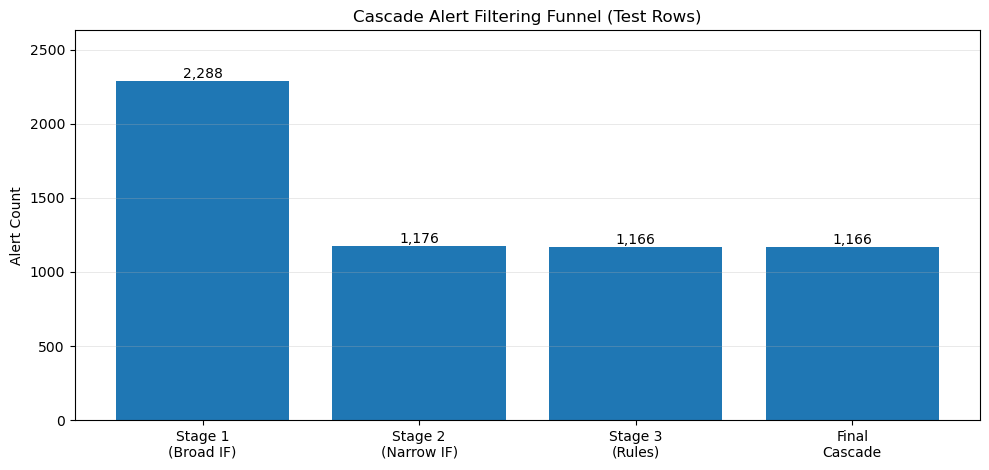

PosixPath('/workspace/artifacts/gold/pump/pump__gold__alert_filtering_funnel.png')

In [15]:


baseline_vs_cascade_summary = load_json(BASELINE_VS_CASCADE_SUMMARY_PATH)


stages = ["Stage 1\n(Broad IF)", "Stage 2\n(Narrow IF)", "Stage 3\n(Rules)", "Final\nCascade"]
counts = [
    baseline_vs_cascade_summary["stage1_alert_count_test_rows"],
    baseline_vs_cascade_summary["stage2_alert_count_test_rows"],
    baseline_vs_cascade_summary.get("stage3_alert_count_test_rows", baseline_vs_cascade_summary["final_cascade_alert_count_test_rows"]),  # fallback
    baseline_vs_cascade_summary["final_cascade_alert_count_test_rows"],
]

fig, ax = plt.subplots(figsize=(10, 4.8))
bars = ax.bar(stages, counts)
ax.set_title("Cascade Alert Filtering Funnel (Test Rows)")
ax.set_ylabel("Alert Count")

for b, c in zip(bars, counts):
    ax.text(b.get_x() + b.get_width()/2, b.get_height(), f"{c:,}", ha="center", va="bottom")

ax.set_ylim(0, max(counts) * 1.15)
ax.grid(axis="y", linestyle="-", linewidth=0.5, alpha=0.4)

out_path = GOLD_ARTIFACTS_PATH / "pump__gold__alert_filtering_funnel.png"
plt.tight_layout()
plt.savefig(out_path, dpi=200)
plt.show()

out_path

----


Next Steps:

How could we improve our results with the highest ROI first? 

Tune our thresholds as decision variables, do not just use a “percentiles” threshold. 
    Performance is dominated currently the chosen thresholds for 
    - Stage 1 score → flag
    - Stage 2 score → flag
    - Stage 3 evidence → final flag

    So one method we can attempt to improve the score would be to switch away from a fixed percentiles to something like a simple grid search. 

    Using Grid Search, we would want to perform the search over the following items:
    - stage1_threshold_percentile (or absolute threshold)
    - stage2_threshold_percentile
    - min_rule_evidence (stage 3)
    - persistence_window / min_consecutive_points

    Objective Options:
    - Max F1 (Which is what we are already doing)
    - Max precision subject to recall greater than or eaqual to X, this is very defensible operationally.
    - Min alerts subject to recall greater than or equal to X

    These alone are often more likely to help improve our model's precision/f1 more than tuning the hyperparameters. 


Isolation Forest Hyperparameter Tuning:

If we do move to hyperparameter tuning, we should prioritize these:
- contamination: huge impact on alert volume. Even if you still threshold via score percentile, contamination affects tree structure and score distribution.
- n_estimators: stability of scores (more trees = smoother).
- max_samples: controls variance; can reduce noisy boundaries.
- max_features: can help when many sensors are irrelevant at a given time.
- bootstrap: sometimes stabilizes scoring.

If we have to choose only hyperparameter, it should be contamination but it should be paired with thresholding tuning as well. 



If we encounter a “Precision Ceiling”, then we should fix it with event-aware evaluation. 

Which is likely since we only have ~7 failure events across the year, row-level labeling is brutally imbalanced, without the use of a synthetic data generator. 

Then the two areas of improvements that often can raise our measured precision and better match real monitoring are:
- Event-window labeling: treat a detection as TP if it happens within a window before/after the event onset (e.g., ±N steps).
- Alert de-duplication: collapse consecutive flagged rows into one “incident.” (Precision becomes “% of incidents that correspond to real events” instead of “% of rows.”)

This may feel like cheating, but it's actually more closely align to realistic operation procedure. 




# Future Improvements:


Stage 3 Changes:

Stage 3 is very weak, it is too weak and needs to be more discriminative or to act earlier like a gating mechanism. 

Upgrade Options:
1) Add hysteresis + Cooldown:
    This will reduce false positives without destroying our recall.  It does this by not flagging every row that meets evidence but instead by:
    - requiring a higher threshold to enter.
    - lowering the exit threshold 
    - adding a cool down so noisy fluctuations do not generate repeated alerts.

This ulimately cuts spams and increases perceived precision 

2) Make stage 3's evidence be weighted instead of counted:
    Right now we are simply adding profile breaches to corroboration to persistence to get our evidence count. 
    Instead we should add a weight multiplier to each item and only alert if the evidence score is over a threshold amount, like so:
        evidence_score = weight_1 * persistence + weight_2 * profile_breach + weight_3 * subsystem_corroboration + weight_4 * drift
        if evidence_score greather than or equal to threshold, then alert. 

This makes the decision boundaires tunable which tends to help improve the F1 score. 
     
3) Subsystem Corrobration Rules (this wone will have the best realism feel to it)
    - Here we would need to implement the subsystem grouping and fault propration. 
        - Example: If sensor 1 breaches, expect to see sensor B and/or sensor C to move within K steps.
        - Require something like a 2 of N sensors in the same subsystem to corroborate the anomaly occurance before alert. 

4) Replace our persistent detection with shape detection. 
    Currently we are only looking for steady noise but by changing it we are looking for degradtion not just that it stayed weird/noisy. 
        With this we would use something like a slopve/curvature features over a short window checking for:
            - rolling mean delta
            - rolling z-score change
            - monotonic trend check



       
Extra Stages:

If we were to add a fourth stage, then that stage should do something like Incident clustering with top contributors. 

Doing Incident clustering + top contributors means that we will cluster our alert windows into incidents, then compute “top sensors driving anomaly”, something like a simple: z-score magnitude or feature contribution proxy, and finally we would output the incident summary (start, peak, sensors involve). This won't change precision directly, but it makes our system look far more production-ready and helps really cover all grounds. 



Stage3 Redesign:
- Weighted evidence score
- Subsystem corroboration (2-of-N sensors in same subsystem)
- Hysteresis + cooldown (enter/exit thresholds, plus incident suppression)
- Incident de-dup metrics (incident-level precision/recall/F1 using your truth events)



----

In [16]:
required_comparison_meta_columns = [
    "meta__truth_hash",
    "meta__parent_truth_hash",
    "meta__pipeline_mode",
]

missing_comparison_meta_columns = [
    column_name
    for column_name in required_comparison_meta_columns
    if column_name not in comparison_df.columns
]
if missing_comparison_meta_columns:
    raise ValueError(
        f"comparison_df is missing required lineage columns: {missing_comparison_meta_columns}"
    )

comparison_df_truth_hash_check = extract_truth_hash(comparison_df)
if comparison_df_truth_hash_check is None:
    raise ValueError("comparison_df does not contain a readable meta__truth_hash value.")

if comparison_df_truth_hash_check != COMPARISON_TRUTH_HASH:
    raise ValueError(
        "comparison_df truth hash does not match COMPARISON_TRUTH_HASH:\n"
        f"dataframe={comparison_df_truth_hash_check}\n"
        f"record={COMPARISON_TRUTH_HASH}"
    )

comparison_parent_values = comparison_df["meta__parent_truth_hash"].dropna().astype(str).unique().tolist()
if not comparison_parent_values:
    raise ValueError("comparison_df is missing populated meta__parent_truth_hash values.")

if len(comparison_parent_values) != 1:
    raise ValueError(f"comparison_df has multiple parent truth hashes: {comparison_parent_values}")

if comparison_parent_values[0] != GOLD_PARENT_TRUTH_HASH:
    raise ValueError(
        "comparison_df parent truth hash does not match GOLD_PARENT_TRUTH_HASH:\n"
        f"dataframe_parent={comparison_parent_values[0]}\n"
        f"gold_parent={GOLD_PARENT_TRUTH_HASH}"
    )

if not Path(comparison_truth_path).exists():
    raise FileNotFoundError(f"Comparison truth file was not created: {comparison_truth_path}")

loaded_comparison_truth = load_json(comparison_truth_path)

if loaded_comparison_truth.get("truth_hash") != COMPARISON_TRUTH_HASH:
    raise ValueError(
        "Saved Comparison truth file hash does not match COMPARISON_TRUTH_HASH:\n"
        f"file={loaded_comparison_truth.get('truth_hash')}\n"
        f"record={COMPARISON_TRUTH_HASH}"
    )

if loaded_comparison_truth.get("parent_truth_hash") != GOLD_PARENT_TRUTH_HASH:
    raise ValueError(
        "Saved Comparison truth file parent hash does not match GOLD_PARENT_TRUTH_HASH:\n"
        f"truth={loaded_comparison_truth.get('parent_truth_hash')}\n"
        f"gold_parent={GOLD_PARENT_TRUTH_HASH}"
    )

saved_comparison_summary = load_json(BASELINE_VS_CASCADE_SUMMARY_PATH)
if saved_comparison_summary.get("comparison_truth_hash") != COMPARISON_TRUTH_HASH:
    raise ValueError(
        "comparison_summary comparison_truth_hash does not match COMPARISON_TRUTH_HASH:\n"
        f"summary={saved_comparison_summary.get('comparison_truth_hash')}\n"
        f"record={COMPARISON_TRUTH_HASH}"
    )

if saved_comparison_summary.get("baseline_truth_hash") != BASELINE_TRUTH_HASH:
    raise ValueError(
        "comparison_summary baseline_truth_hash does not match BASELINE_TRUTH_HASH:\n"
        f"summary={saved_comparison_summary.get('baseline_truth_hash')}\n"
        f"baseline={BASELINE_TRUTH_HASH}"
    )

if saved_comparison_summary.get("cascade_truth_hash") != CASCADE_TRUTH_HASH:
    raise ValueError(
        "comparison_summary cascade_truth_hash does not match CASCADE_TRUTH_HASH:\n"
        f"summary={saved_comparison_summary.get('cascade_truth_hash')}\n"
        f"cascade={CASCADE_TRUTH_HASH}"
    )

if saved_comparison_summary.get("gold_truth_hash") != GOLD_PARENT_TRUTH_HASH:
    raise ValueError(
        "comparison_summary gold_truth_hash does not match GOLD_PARENT_TRUTH_HASH:\n"
        f"summary={saved_comparison_summary.get('gold_truth_hash')}\n"
        f"gold={GOLD_PARENT_TRUTH_HASH}"
    )

print("Gold Comparison lineage sanity check passed.")

2026-03-13 07:55:57,193 | INFO | capstone.file_io | Loading JSON: /workspace/artifacts/truths/gold_comparison/pump__gold_comparison__truth__3b9dfd95185f4b136e4fef1c8a6a8f22e4496e50b16045ed514e7285245850c8.json
2026-03-13 07:55:57,223 | INFO | capstone.file_io | Loading JSON: /workspace/artifacts/gold/pump/pump__gold__baseline_vs_cascade_summary.json


Gold Comparison lineage sanity check passed.


----